# SHAP Explainability
SHAP (SHapley Additive exPlanations) explains *why* the model made each individual prediction.
Rather than just knowing which features matter overall, SHAP tells us exactly how much
each feature pushed a specific loan toward or away from default.

**Sections:**
1. Setup & compute SHAP values
2. Global summary plot (beeswarm)
3. Mean absolute SHAP bar plot
4. Single loan waterfall — explain one prediction
5. DTI dependence plot
6. High-risk vs low-risk loan comparison
7. Key takeaways

## 1. Setup & Compute SHAP Values

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pickle
import shap
import warnings
warnings.filterwarnings('ignore')

# Load model and test data
X_test = pd.read_parquet('../data/X_test.parquet').drop(columns=['installment', 'total_acc'])
y_test = pd.read_parquet('../data/y_test.parquet').squeeze()

with open('../data/xgb_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('../data/threshold.txt') as f:
    THRESHOLD = float(f.read())

print('Model loaded.')
print('Test set shape:', X_test.shape)
print('Threshold:', THRESHOLD)

# Predict probabilities
proba = model.predict_proba(X_test)[:, 1]
preds = (proba >= THRESHOLD).astype(int)

Model loaded.
Test set shape: (269612, 34)
Threshold: 0.35


In [11]:
# Compute SHAP values using a sample (full test set is 270K rows — too slow)
# 5,000 rows gives stable, representative SHAP values in ~1-2 minutes
print('Sampling 5,000 rows for SHAP computation...')
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=5000, replace=False)
X_sample   = X_test.iloc[sample_idx].reset_index(drop=True)
y_sample   = y_test.iloc[sample_idx].reset_index(drop=True)
p_sample   = proba[sample_idx]

print('Computing SHAP values (TreeExplainer — fast for XGBoost)...')
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print('Done. SHAP values shape:', shap_values.shape)
print('Expected value (base rate):', explainer.expected_value.round(4))

Sampling 5,000 rows for SHAP computation...
Computing SHAP values (TreeExplainer — fast for XGBoost)...
Done. SHAP values shape: (5000, 34)
Expected value (base rate): 0.0047


## 2. Global Summary Plot (Beeswarm)
Each dot is one loan. Position on X-axis = how much that feature pushed the prediction
toward default (positive) or away from default (negative).
Colour = the actual feature value (red = high, blue = low).

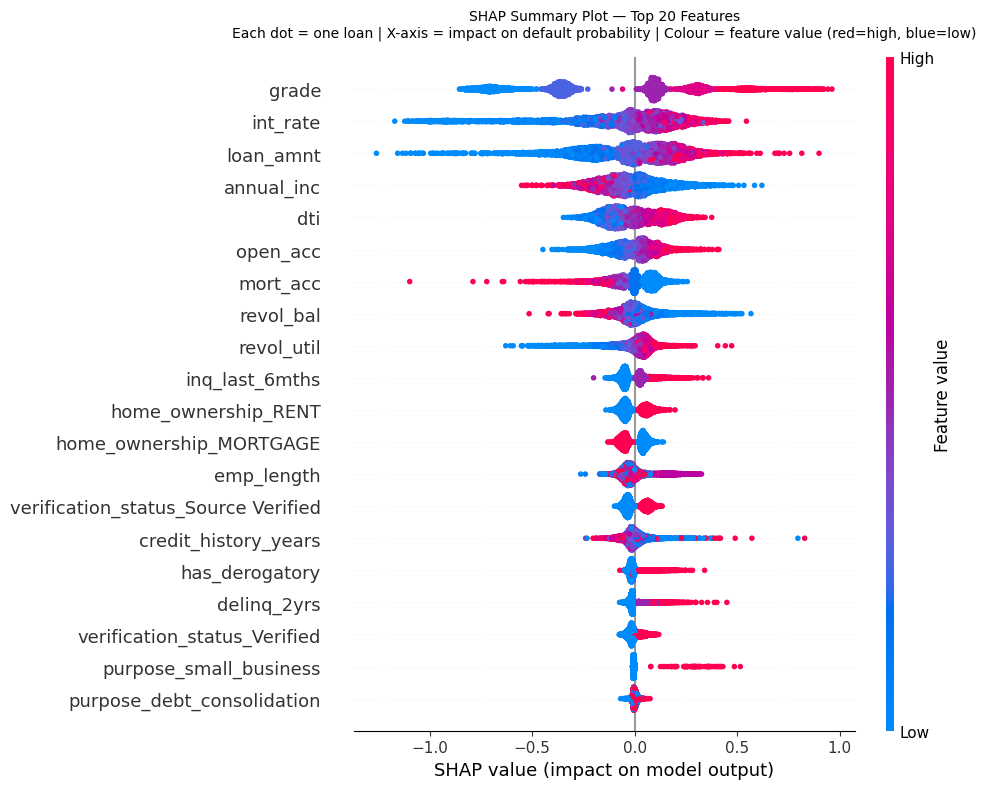

Saved: shap_summary.png


In [12]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_sample,
    max_display=20,
    show=False,
    plot_size=(10, 8)
)
plt.title('SHAP Summary Plot — Top 20 Features\n'
          'Each dot = one loan | X-axis = impact on default probability | '
          'Colour = feature value (red=high, blue=low)',
          fontsize=10, pad=15)
plt.tight_layout()
plt.savefig('../data/shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: shap_summary.png')

## 3. Mean Absolute SHAP — Feature Importance Bar Chart
The average magnitude of each feature's SHAP value across all loans.
This is a more rigorous version of XGBoost's built-in feature importance.

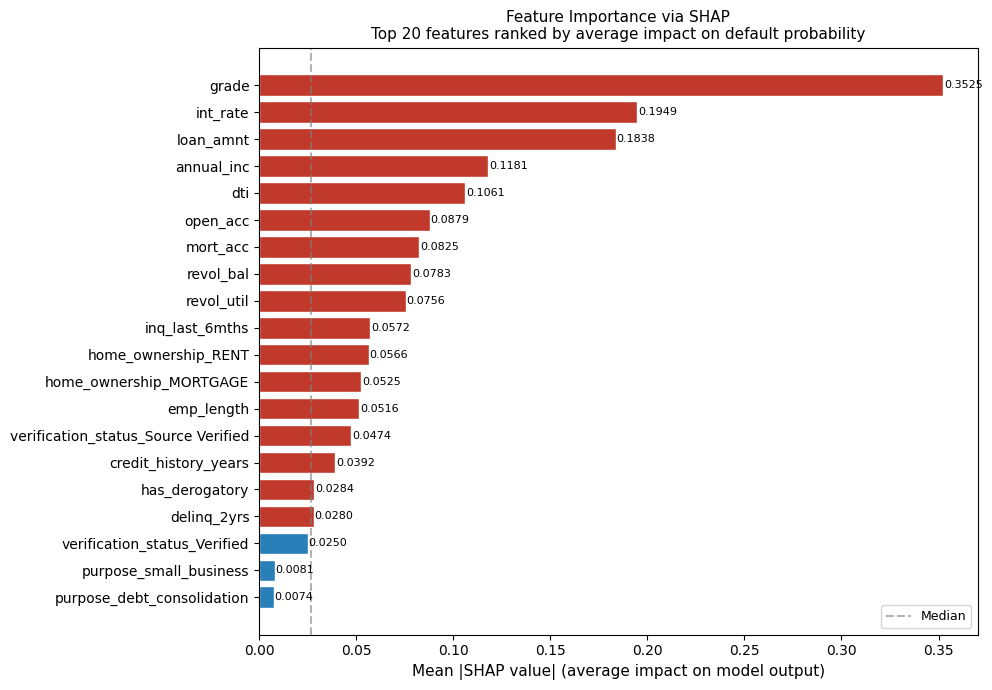

Top 10 features by mean |SHAP|:
grade             0.35248
int_rate          0.19490
loan_amnt         0.18378
annual_inc        0.11813
dti               0.10614
open_acc          0.08789
mort_acc          0.08247
revol_bal         0.07833
revol_util        0.07557
inq_last_6mths    0.05720


In [13]:
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_sample.columns
).sort_values(ascending=True)

top20 = mean_abs_shap.tail(20)
colors = ['#C0392B' if v > mean_abs_shap.median() else '#2980B9' for v in top20]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top20.index, top20.values, color=colors, edgecolor='white')
for bar, val in zip(bars, top20.values):
    ax.text(val + 0.0003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
ax.set_xlabel('Mean |SHAP value| (average impact on model output)', fontsize=11)
ax.set_title('Feature Importance via SHAP\nTop 20 features ranked by average impact on default probability',
             fontsize=11)
ax.axvline(mean_abs_shap.median(), color='gray', linestyle='--', alpha=0.6, label='Median')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../data/shap_bar.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 10 features by mean |SHAP|:')
print(mean_abs_shap.sort_values(ascending=False).head(10).round(5).to_string())

## 4. Waterfall Plot — Explaining a Single Loan
Pick one high-risk loan and one low-risk loan, and show exactly which features
pushed the model's prediction up or down from the base rate.

**How to read it:**
- Start from E[f(x)] — the average model output across all loans (base rate)
- Red bars push the prediction HIGHER (toward default)
- Blue bars push the prediction LOWER (away from default)
- The final value f(x) is the model's predicted default probability for that loan

In [14]:
# Pick a high-risk loan (high predicted probability, actually defaulted)
high_risk_mask = (y_sample == 1) & (p_sample >= 0.7)
if high_risk_mask.sum() == 0:
    high_risk_mask = (p_sample >= p_sample.quantile(0.95))
high_risk_idx = np.where(high_risk_mask)[0][0]

# Pick a low-risk loan (low predicted probability, actually paid)
low_risk_mask = (y_sample == 0) & (p_sample <= 0.15)
if low_risk_mask.sum() == 0:
    low_risk_mask = (p_sample <= p_sample.quantile(0.05))
low_risk_idx = np.where(low_risk_mask)[0][0]

print(f'High-risk loan index: {high_risk_idx}')
print(f'  Predicted probability: {p_sample[high_risk_idx]:.3f}')
print(f'  Actual outcome: {"DEFAULT" if y_sample.iloc[high_risk_idx]==1 else "PAID"}')
print()
print(f'Low-risk loan index: {low_risk_idx}')
print(f'  Predicted probability: {p_sample[low_risk_idx]:.3f}')
print(f'  Actual outcome: {"DEFAULT" if y_sample.iloc[low_risk_idx]==1 else "PAID"}')

High-risk loan index: 57
  Predicted probability: 0.883
  Actual outcome: DEFAULT

Low-risk loan index: 2
  Predicted probability: 0.111
  Actual outcome: PAID


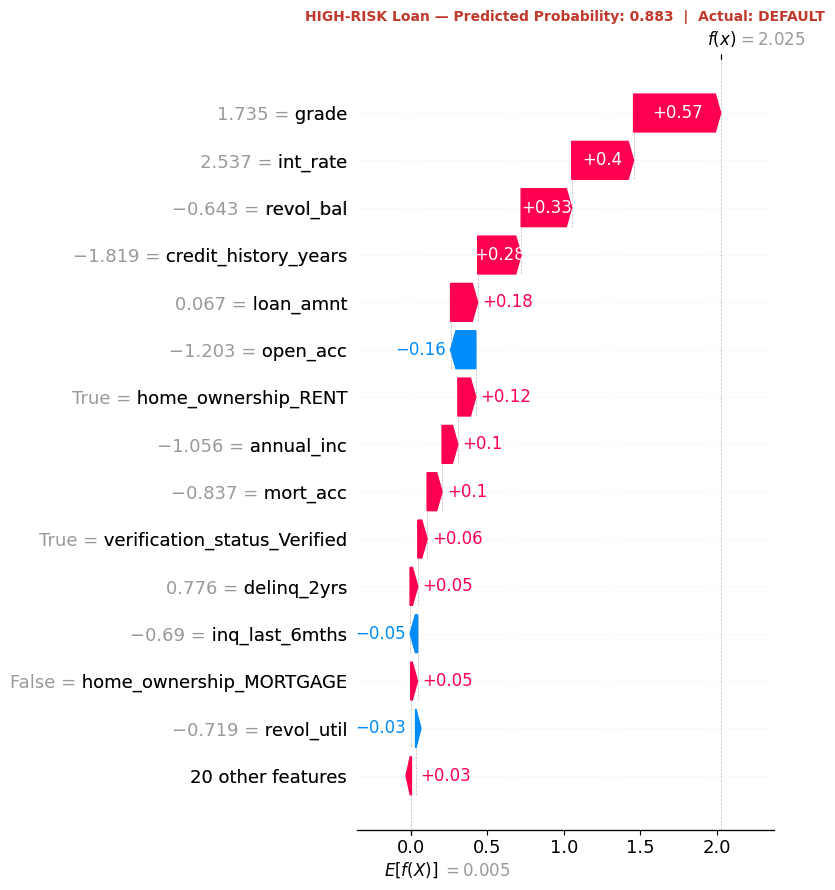

Saved: shap_waterfall_high.png


In [15]:
# ── High-risk waterfall ──────────────────────────────────────────────────────
explanation_high = shap.Explanation(
    values        = shap_values[high_risk_idx],
    base_values   = explainer.expected_value,
    data          = X_sample.iloc[high_risk_idx].values,
    feature_names = X_sample.columns.tolist()
)

plt.figure(figsize=(10, 7))
shap.plots.waterfall(explanation_high, max_display=15, show=False)
plt.title(f'HIGH-RISK Loan — Predicted Probability: {p_sample[high_risk_idx]:.3f}  |  '
          f'Actual: {"DEFAULT" if y_sample.iloc[high_risk_idx]==1 else "PAID"}',
          fontsize=10, color='#C0392B', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_waterfall_high.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: shap_waterfall_high.png')

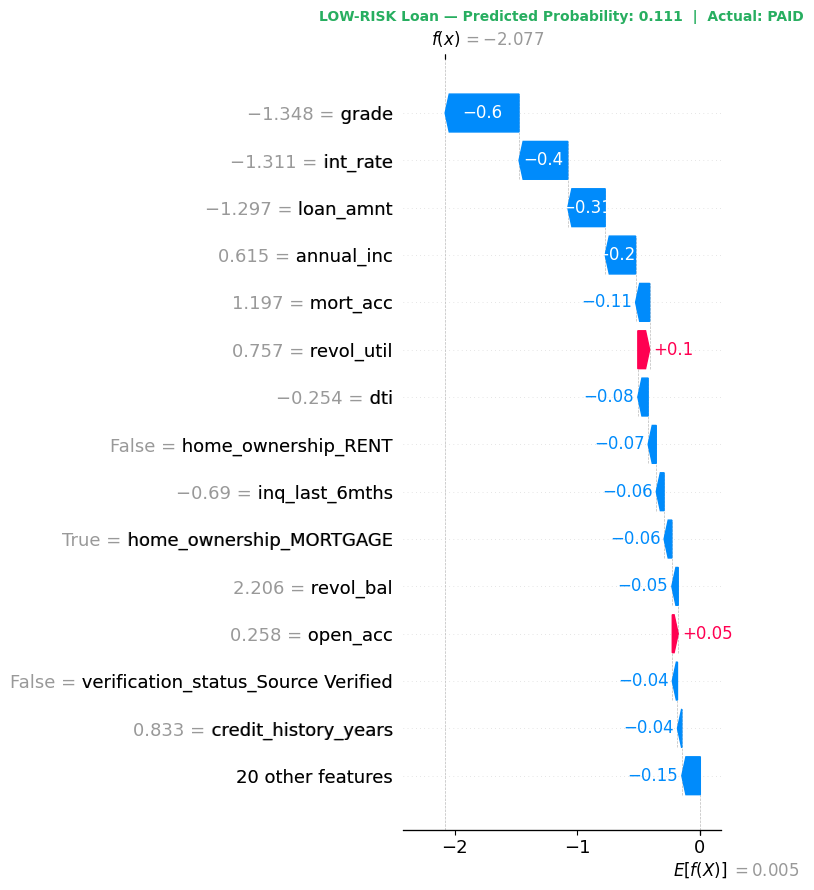

Saved: shap_waterfall_low.png


In [16]:
# ── Low-risk waterfall ───────────────────────────────────────────────────────
explanation_low = shap.Explanation(
    values        = shap_values[low_risk_idx],
    base_values   = explainer.expected_value,
    data          = X_sample.iloc[low_risk_idx].values,
    feature_names = X_sample.columns.tolist()
)

plt.figure(figsize=(10, 7))
shap.plots.waterfall(explanation_low, max_display=15, show=False)
plt.title(f'LOW-RISK Loan — Predicted Probability: {p_sample[low_risk_idx]:.3f}  |  '
          f'Actual: {"DEFAULT" if y_sample.iloc[low_risk_idx]==1 else "PAID"}',
          fontsize=10, color='#27AE60', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_waterfall_low.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: shap_waterfall_low.png')

## 5. Dependence Plots — How Feature Values Drive Predictions
Shows the relationship between a feature's value (X-axis) and its SHAP value (Y-axis).
The colour shows the value of the most interacting feature.
This reveals non-linear relationships and interaction effects the model learned.

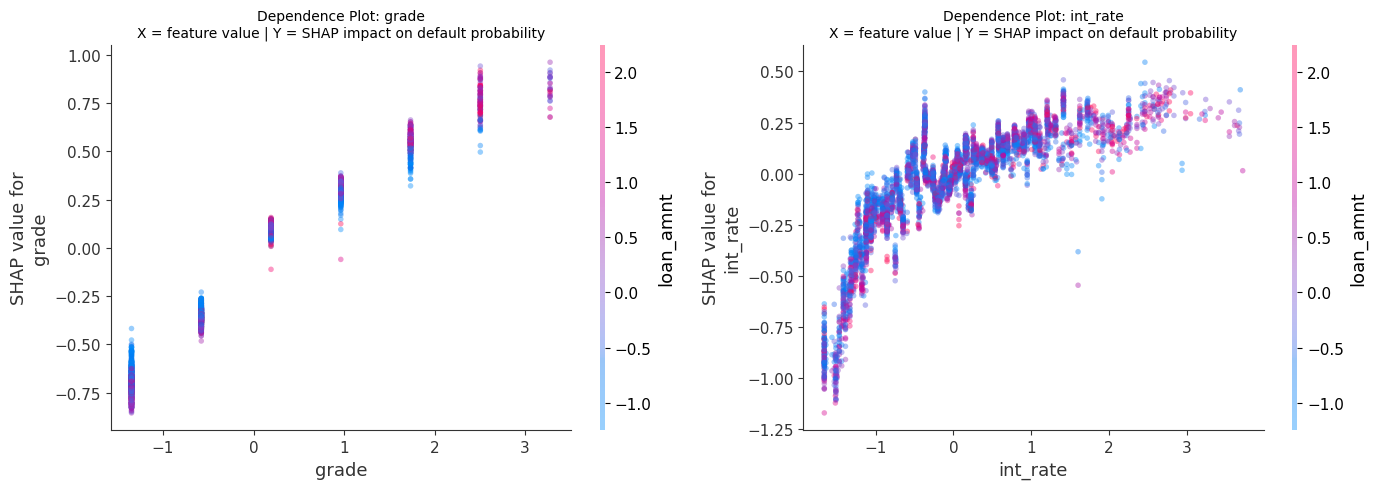

Saved: shap_dependence.png  (features: grade, int_rate)


In [17]:
# Find top feature by mean |SHAP|
top_features = mean_abs_shap.sort_values(ascending=False).index.tolist()
feat1 = top_features[0]
feat2 = top_features[1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature 1
shap.dependence_plot(
    feat1, shap_values, X_sample,
    ax=axes[0], show=False, alpha=0.4
)
axes[0].set_title(f'Dependence Plot: {feat1}\n'
                  f'X = feature value | Y = SHAP impact on default probability',
                  fontsize=10)

# Feature 2
shap.dependence_plot(
    feat2, shap_values, X_sample,
    ax=axes[1], show=False, alpha=0.4
)
axes[1].set_title(f'Dependence Plot: {feat2}\n'
                  f'X = feature value | Y = SHAP impact on default probability',
                  fontsize=10)

plt.tight_layout()
plt.savefig('../data/shap_dependence.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: shap_dependence.png  (features: {feat1}, {feat2})')

## 6. High-Risk vs Low-Risk Loan Profile Comparison
Side-by-side comparison of the actual feature values for the two loans we explained above.
This makes the waterfall plots concrete and easy to interpret.

In [18]:
high_loan = X_sample.iloc[high_risk_idx]
low_loan  = X_sample.iloc[low_risk_idx]

# Show top 15 features by mean |SHAP|
top15_feats = mean_abs_shap.sort_values(ascending=False).head(15).index.tolist()

comparison = pd.DataFrame({
    'Feature':          top15_feats,
    'High-Risk Value':  [round(float(high_loan[f]), 3) for f in top15_feats],
    'Low-Risk Value':   [round(float(low_loan[f]),  3) for f in top15_feats],
    'SHAP (High-Risk)': [round(float(shap_values[high_risk_idx][X_sample.columns.get_loc(f)]), 4) for f in top15_feats],
    'SHAP (Low-Risk)':  [round(float(shap_values[low_risk_idx][X_sample.columns.get_loc(f)]),  4) for f in top15_feats],
})

print(f'HIGH-RISK loan  — predicted prob: {p_sample[high_risk_idx]:.3f}  |  actual: {"DEFAULT" if y_sample.iloc[high_risk_idx]==1 else "PAID"}')
print(f'LOW-RISK  loan  — predicted prob: {p_sample[low_risk_idx]:.3f}  |  actual: {"DEFAULT" if y_sample.iloc[low_risk_idx]==1 else "PAID"}')
print()
print(comparison.to_string(index=False))

HIGH-RISK loan  — predicted prob: 0.883  |  actual: DEFAULT
LOW-RISK  loan  — predicted prob: 0.111  |  actual: PAID

                            Feature  High-Risk Value  Low-Risk Value  SHAP (High-Risk)  SHAP (Low-Risk)
                              grade            1.735          -1.348            0.5693          -0.6026
                           int_rate            2.537          -1.311            0.4044          -0.3975
                          loan_amnt            0.067          -1.297            0.1769          -0.3052
                         annual_inc           -1.056           0.615            0.1030          -0.2480
                                dti            0.389          -0.254            0.0291          -0.0842
                           open_acc           -1.203           0.258           -0.1647           0.0486
                           mort_acc           -0.837           1.197            0.0977          -0.1148
                          revol_bal           -0.6

## 7. Key Takeaways

In [19]:
top5 = mean_abs_shap.sort_values(ascending=False).head(5)

print('=' * 60)
print('         SHAP EXPLAINABILITY — KEY TAKEAWAYS')
print('=' * 60)
print()
print('TOP 5 FEATURES BY MEAN |SHAP|:')
for rank, (feat, val) in enumerate(top5.items(), 1):
    print(f'  {rank}. {feat:30s}  mean |SHAP| = {val:.5f}')
print()
print('WHAT SHAP ADDS OVER STANDARD FEATURE IMPORTANCE:')
print('  - Direction: does a HIGH value of this feature increase or decrease default risk?')
print('  - Magnitude: by exactly how much does each feature shift the probability?')
print('  - Individual: explains every single loan prediction, not just the model overall')
print('  - Interactions: dependence plots reveal how two features interact')
print()
print('BUSINESS USE:')
print('  - Loan officer can see EXACTLY why a loan was flagged')
print('  - Applicant can be told which factors hurt their application')
print('  - Regulatory compliance: model decisions are fully explainable')
print('=' * 60)

         SHAP EXPLAINABILITY — KEY TAKEAWAYS

TOP 5 FEATURES BY MEAN |SHAP|:
  1. grade                           mean |SHAP| = 0.35248
  2. int_rate                        mean |SHAP| = 0.19490
  3. loan_amnt                       mean |SHAP| = 0.18378
  4. annual_inc                      mean |SHAP| = 0.11813
  5. dti                             mean |SHAP| = 0.10614

WHAT SHAP ADDS OVER STANDARD FEATURE IMPORTANCE:
  - Direction: does a HIGH value of this feature increase or decrease default risk?
  - Magnitude: by exactly how much does each feature shift the probability?
  - Individual: explains every single loan prediction, not just the model overall
  - Interactions: dependence plots reveal how two features interact

BUSINESS USE:
  - Loan officer can see EXACTLY why a loan was flagged
  - Applicant can be told which factors hurt their application
  - Regulatory compliance: model decisions are fully explainable
